In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys, pathlib

# adjust this to your repo root if different
repo_root = pathlib.Path.cwd()

repo_root = repo_root.parent.parent

sys.path.insert(0, str(repo_root))
print('Inserted repo root into sys.path:', repo_root)

Inserted repo root into sys.path: /Users/fabian/qecsim


In [3]:
import pandas as pd
import json
import numpy as np
from matplotlib import pyplot as plt

**THRESHOLD ANAYISIS**

In [4]:
# Load in CSV files
memory_csv = pd.read_csv(repo_root / "thesis" / "data" / "stats_memory_X+_X.csv")
surgery_csv = pd.read_csv(repo_root / "thesis" / "data" / "stats_surgery_X+_I0_X_X.csv")

# Load in Stats files
memory_path = repo_root / "thesis" / "data" / "stats_memory_X+_X.csv"
surgery_path = repo_root / "thesis" / "data" / "stats_surgery_X+_I0_X_X.csv"

In [5]:
def get_threshold_data(sinter_stats, distances=None):
    """
    Process the raw stats DataFrame to extract p and d, filter for specified distances,
    and compute the logical error rates grouped by (d, p).
    
    Args:
        sinter_stats: Input DataFrame with sinter stats
        distances: List of distances to include. If None, includes all distances
    """

    sinter_stats.columns = sinter_stats.columns.str.strip()

    # Extract p and d from json_metadata
    sinter_stats['p'] = sinter_stats['json_metadata'].str.strip().apply(lambda s: json.loads(s)['p'])
    sinter_stats['d'] = sinter_stats['json_metadata'].str.strip().apply(lambda s: json.loads(s)['d'])

    # Filter by distances if specified, otherwise keep all
    if distances is not None:
        sinter_stats = sinter_stats[sinter_stats['d'].isin(distances)]

    # Group by both distance and physical error rate
    grouped = sinter_stats.groupby(['d', 'p']).agg(
        total_shots=('shots', 'sum'),
        total_errors=('errors', 'sum'),
    ).reset_index()

    grouped['logical_error_rate'] = grouped['total_errors'] / grouped['total_shots']
    grouped = grouped.sort_values(['d', 'p']).reset_index(drop=True)

    # Dict keyed by distance, each containing sorted p and p_L lists
    # As well as total shots and errors later used to get the binomial distribution...
    data = {
        d: {
            'p': group['p'].tolist(),
            'p_L': group['logical_error_rate'].tolist(),
            'total_shots':  group['total_shots'].tolist(),
            'total_errors': group['total_errors'].tolist(),
        }
        for d, group in grouped.groupby('d')
    }

    return data


In [6]:
def fit_threshold(data, p_th_approx, fit_distances=[7, 9]):
    """
    1. Fits log-log power law once per distance
    2. Finds p_th from the line intersection
    3. Derives A and RMSE from the same fit
    
    Returns: p_th, {d: {'slope', 'A', 'rmse'}}
    """
    raw_fits = {}

    for d in fit_distances:
        if d not in data:
            continue

        p   = np.array(data[d]['p'])
        p_L = np.array(data[d]['p_L'])

        mask = (p > 0) & (p_L > 0) & (p < p_th_approx)
        p, p_L = p[mask], p_L[mask]

        slope, intercept = np.polyfit(np.log10(p), np.log10(p_L), 1)
        raw_fits[d] = (slope, intercept, p, p_L)

    # --- Find p_th from intersection ---
    (s1, b1, _, _), (s2, b2, _, _) = [raw_fits[d] for d in fit_distances]

    if abs(s1 - s2) < 1e-10:
        raise ValueError("Lines are parallel, cannot find intersection")

    # Find threshold by setting both fittet liens equal
    p_th = 10 ** ((b2 - b1) / (s1 - s2))

    # Get A and RMSE
    results = {}
    for d, (slope, intercept, p, p_L) in raw_fits.items():

        # Normalize fit parameter to get A
        A    = 10 ** (intercept + slope * np.log10(p_th))
        
        log_pL_fit = np.log10(A) + slope * (np.log10(p) - np.log10(p_th))
        rmse = np.sqrt(np.mean((np.log10(p_L) - log_pL_fit) ** 2))

        results[d] = {'slope': slope, 'A': A, 'rmse': rmse}

    return p_th, results

In [ ]:
def bootstrap_analysis(data, p_th_approx, fit_distances=[7, 9], n_bootstrap=1000, seed=42):
    """
    Covariant Matrix does assume gaussian and not binomial statistics
    -> Also I think p_th needs to be constant which is not the case since we have errors!

    -> We include a seed for reproduction of values

    Bootstrap does the following:
        - We sample from our actual data with a given phy prob. and the logical error rate
        - Each logical error now per sample gets slightly changed in correspondance to the binomial dist per phy data
        - With new set of data we again perform the fit
        - With different retults ci returns 1-sigma interval
    """

    rng = np.random.default_rng(seed)

    samples = {
        'p_th':  [],
        'A':     {d: [] for d in fit_distances},
        'slope': {d: [] for d in fit_distances},
    }

    for _ in range(n_bootstrap):
        resampled = {}
        for d in fit_distances:
            # Initilize the resampled entry for a given distance, load in the same p phys data points
            resampled[d] = {'p': data[d]['p'][:], 'p_L': []}
            # We now calc the logical errors by applying a binomial distribution to get the new logical error
            # rate
            for shots, errors in zip(data[d]['total_shots'], data[d]['total_errors']):
                new_errors = rng.binomial(shots, errors / shots)
                resampled[d]['p_L'].append(new_errors / shots)

        # Now run with the new data again the fit and calc the crossingpoint p_th
        # calculate the slope and A from the fittet curves...
        p_th_s, fit_s = fit_threshold(resampled, p_th_approx, fit_distances)
        samples['p_th'].append(p_th_s)
        for d in fit_distances:
            if d in fit_s:
                samples['A'][d].append(fit_s[d]['A'])
                samples['slope'][d].append(fit_s[d]['slope'])

    def ci(arr):
        arr = np.array(arr)
        return np.percentile(arr, 50), np.percentile(arr, 16), np.percentile(arr, 84)

    return {
        'p_th':  ci(samples['p_th']),
        'A':     {d: ci(samples['A'][d])     for d in fit_distances},
        'slope': {d: ci(samples['slope'][d]) for d in fit_distances},
    }

In [ ]:
def plot_threshold_fit(data, fit_results, p_th, xlim_min, xlim_max, title_name):
    
    fig, ax = plt.subplots(figsize=(8, 6), dpi=150)
    
    # Define the marker cycle
    markers = ['o', 'v', '*', 's', 'D', '^']
    
    for i, (d, vals) in enumerate(sorted(data.items())):
        p    = np.array(vals['p'])
        p_L  = np.array(vals['p_L'])
        
        # Plot data: Scatter points (all distances)
        ax.plot(
            p, p_L, 
            marker=markers[i % len(markers)], 
            linestyle='None', 
            markersize=7, 
            color=f'C{i}', # Ensures marker color matches the fit line
            label=f'd={d}'
        )

        # Plot fit lines only for distances with fit results
        if d in fit_results:
            A = fit_results[d]['A']
            exponent = fit_results[d]['slope']
            p_fit = np.logspace(np.log10(p.min()), np.log10(p_th), 200)
            p_L_fit = A * (p_fit / p_th) ** exponent
            
            ax.plot(
                p_fit, p_L_fit, 
                linestyle='--', 
                linewidth=1.5,
                color=f'C{i}', 
                alpha=0.7
            )

    # Ths line and formatting
    ax.axvline(p_th, color='gray', linestyle='--', linewidth=1.5)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlim(xlim_min, xlim_max) 
    #ax.set_ylim(1e-3, 1e0)
    ax.set_xlabel('Physical Error Rate $p$', fontsize=12)
    ax.set_ylabel('Logical Error Rate $p_L$', fontsize=12)
    ax.set_title(f'{title_name} Circuit-Noise', fontsize=16, weight='bold')
    ax.legend(title='Distance', loc='upper left', framealpha=1.0)
    ax.grid(which='major', linestyle='-', linewidth=0.8, color='#d3d3d3')
    ax.grid(which='minor', linestyle=':', linewidth=0.8, color='#ebebeb')

    plt.tight_layout()
    plt.show()


In [9]:
def print_threshold_summary(bootstrap_results, label=""):
    p_th_mean, p_th_low, p_th_high = bootstrap_results['p_th']

    # Compute asymmetric deviations explicitly
    p_th_sigma_high = p_th_high - p_th_mean
    p_th_sigma_low  = p_th_mean - p_th_low

    w = 72
    print("=" * w)
    print(f"  {label} Threshold Summary".center(w))
    print("=" * w)
    print(f"  p_th = {p_th_mean:.4e}  (+{p_th_sigma_high:.2e} / -{p_th_sigma_low:.2e})")
    print("-" * w)
    print(f"  {'d':>3} | {'A':>8}  {'+σ / -σ':>20} | {'Slope':>7}  {'+σ / -σ':>18}")
    print("-" * w)
    for d in bootstrap_results['A']:
        Am, Al, Ah = bootstrap_results['A'][d]
        Sm, Sl, Sh = bootstrap_results['slope'][d]

        A_up, A_dn = Ah - Am, Am - Al
        S_up, S_dn = Sh - Sm, Sm - Sl

        print(f"  {d:>3} | {Am:>8.4f}  (+{A_up:.4f} / -{A_dn:.4f})  | {Sm:>7.4f}  (+{S_up:.4f} / -{S_dn:.4f})")
    print("=" * w)

                         Memory Threshold Summary                       
  p_th = 3.8939e-03  (+4.30e-04 / -3.07e-04)
------------------------------------------------------------------------
    d |        A               +σ / -σ |   Slope             +σ / -σ
------------------------------------------------------------------------
    7 |   0.0401  (+0.0230 / -0.0114)  |  3.9460  (+0.1206 / -0.0782)
    9 |   0.0401  (+0.0230 / -0.0114)  |  5.0486  (+0.1872 / -0.1246)


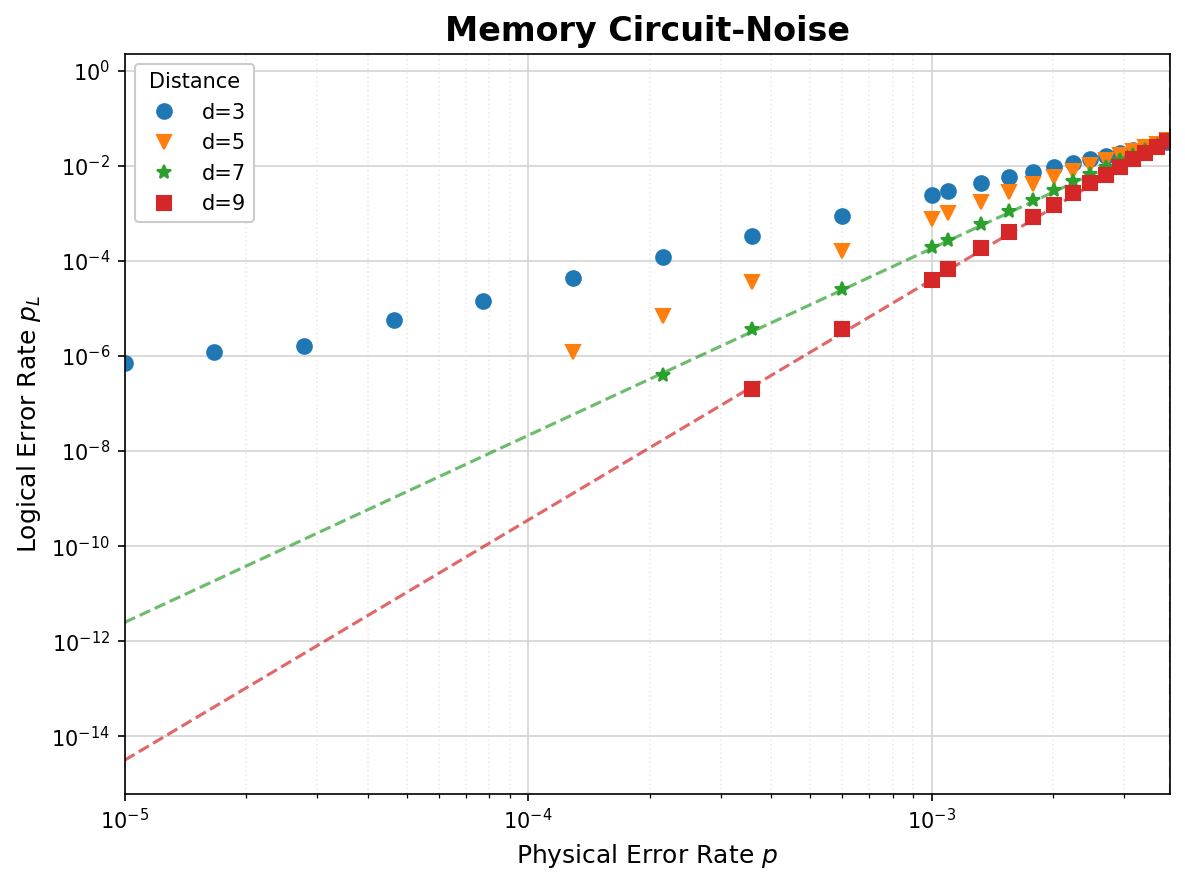

In [10]:
###### MEMORY ######
data_memory = get_threshold_data(memory_csv, distances=[3, 5, 7, 9])

# Get approximate threshold which is then used as proper input for refinement
p_th_memory, _ = fit_threshold(data_memory, p_th_approx=3e-3)#, fit_distances=[3,5])
p_th_memory, _ = fit_threshold(data_memory, p_th_approx=p_th_memory)#, fit_distances=[3,5])

# Perform Bootstrap to get uncertaintiy
bootstrap_results_memory = bootstrap_analysis(data_memory, p_th_approx=p_th_memory)#, fit_distances=[3,5])
print_threshold_summary(bootstrap_results_memory, label="Memory")

_, fit_results_memory = fit_threshold(data_memory, p_th_approx=bootstrap_results_memory['p_th'][0])
plot_threshold_fit(data_memory, fit_results_memory, bootstrap_results_memory['p_th'][0],
                   xlim_min=1e-5, xlim_max=bootstrap_results_memory['p_th'][0], title_name="Memory")


                        Surgery Threshold Summary                       
  p_th = 2.4904e-03  (+1.28e-04 / -9.13e-05)
------------------------------------------------------------------------
    d |        A               +σ / -σ |   Slope             +σ / -σ
------------------------------------------------------------------------
    7 |   0.3730  (+0.0885 / -0.0605)  |  3.7939  (+0.0520 / -0.0673)
    9 |   0.3730  (+0.0885 / -0.0605)  |  4.9815  (+0.0736 / -0.0901)


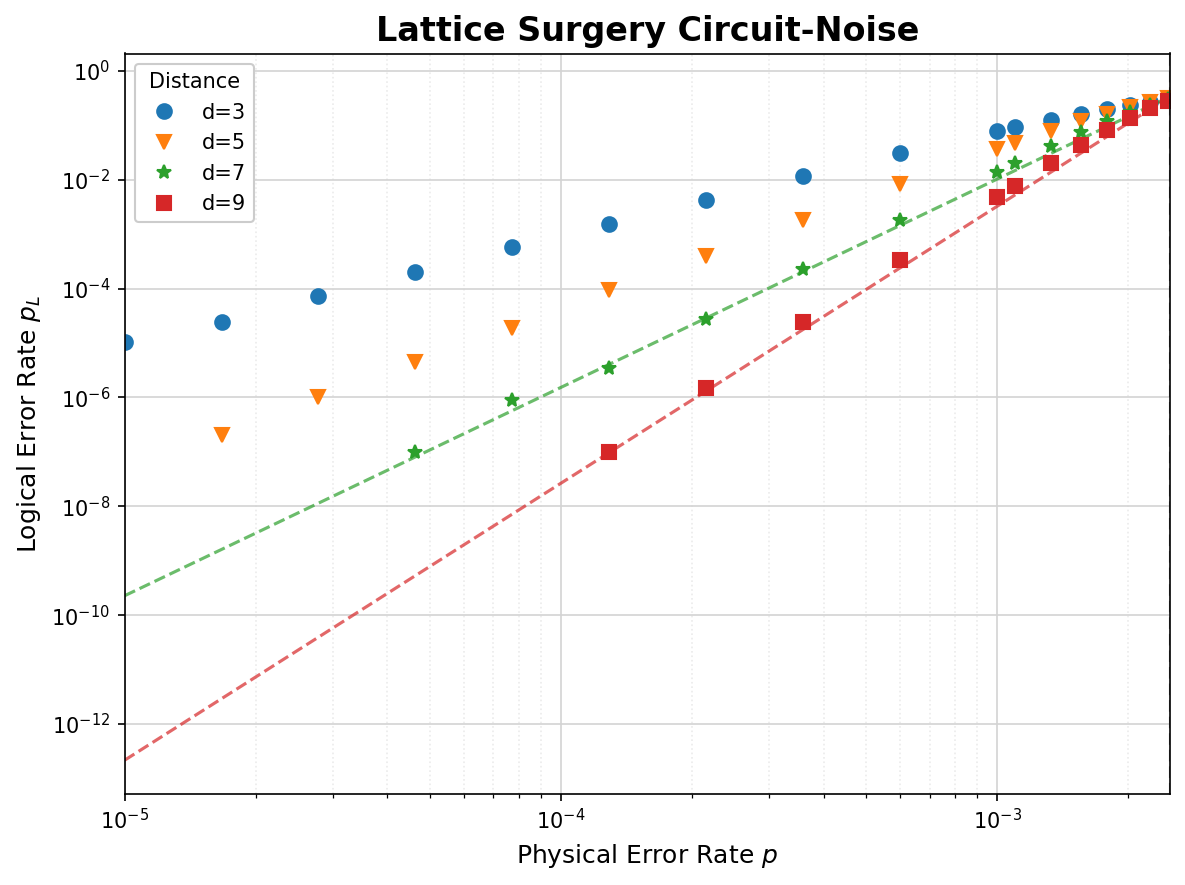

In [11]:
###### SURGERY ######
data_surgery = get_threshold_data(surgery_csv, distances=[3, 5, 7, 9])

p_th_surgery, _ = fit_threshold(data_surgery, p_th_approx=5e-3)#, fit_distances=[3,5])
p_th_surgery, _ = fit_threshold(data_surgery, p_th_approx=p_th_surgery)#, fit_distances=[3,5])

bootstrap_results_surgery = bootstrap_analysis(data_surgery, p_th_approx=p_th_surgery)#, fit_distances=[3,5])
print_threshold_summary(bootstrap_results_surgery, label="Surgery")

_, fit_results_surgery = fit_threshold(data_surgery, p_th_approx=bootstrap_results_surgery['p_th'][0])
plot_threshold_fit(data_surgery, fit_results_surgery, bootstrap_results_surgery['p_th'][0],
                   xlim_min=1e-5, xlim_max=bootstrap_results_surgery['p_th'][0], title_name="Lattice Surgery")